In [6]:
import json
import os
import wandb
import os
import glob
import wandb
import matplotlib.pyplot as plt

In [ ]:
api = wandb.Api()

entity = "maxbrzr-kit"
project = "cae"
version = "v1"


def download_artifacts(artifacts):
    for artifact in artifacts:
        # remove version suffix if present
        base_name = artifact.split(":")[0]

        # search for any directory matching the base name, regardless of version
        existing = glob.glob(f"artifacts/{base_name}:*")

        if existing:
            print(f"skipping {artifact}, found {existing}")
            continue

        try:
            art = api.artifact(f"{entity}/{project}/{artifact}:{version}")
        except Exception as e:
            print(e)
            continue

        art.download(f"{project}_{version}/{artifact}")

In [5]:
architectures = ["cae"]
latent_sizes = [4]
num_latent_channels = [20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64]

models = [
    f"{arch}_nc18_lc{lc}_ls{ls}"
    for arch in architectures
    for lc in num_latent_channels
    for ls in latent_sizes
]

model_artifacts = [f"model_{model}" for model in models]
metrics_artifacts = [f"metrics_{model}" for model in models]
config_artifacts = [f"config_{model}" for model in models]

download_artifacts(model_artifacts)
download_artifacts(metrics_artifacts)
download_artifacts(config_artifacts)

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downlo

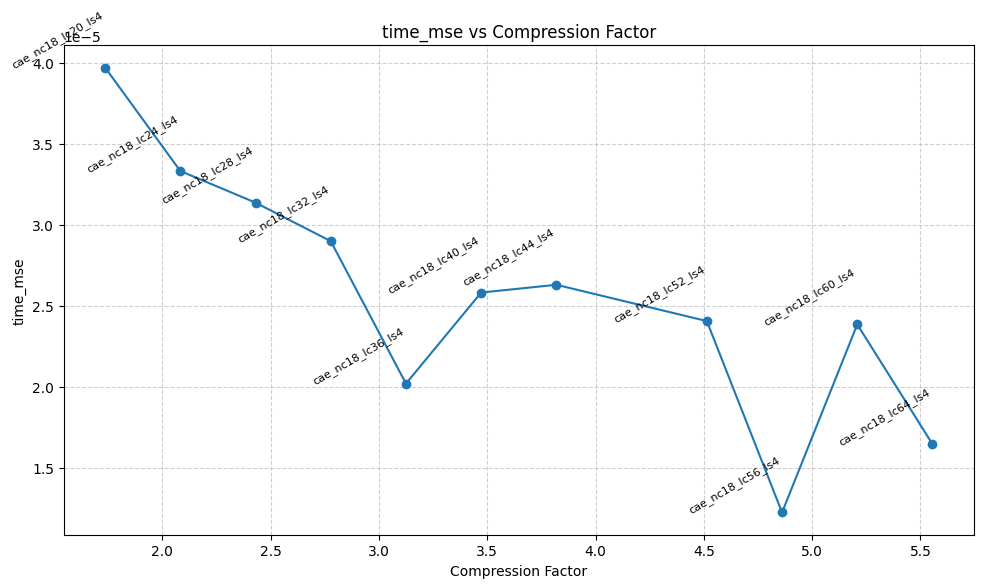

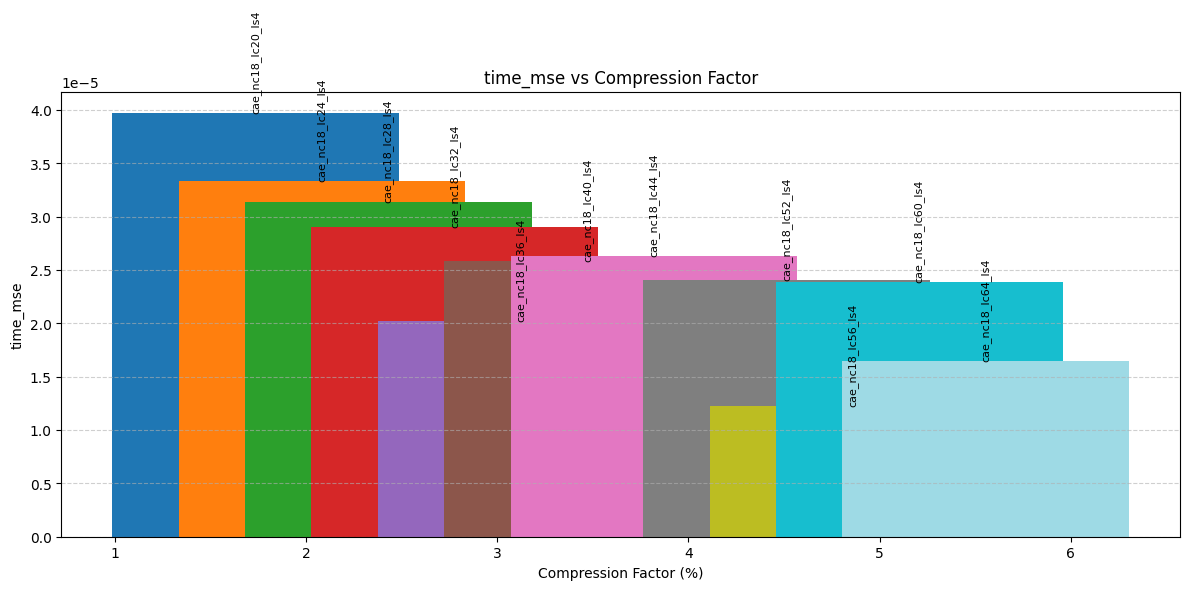

In [7]:
root_dir = "artifacts:v0"
key = "time_mse"
original_size = 18 * 32 * 32

configs = {}
metrics = {}

# Walk through artifacts and collect config.json and metrics.json
for dirpath, _, filenames in os.walk(root_dir):
    for filename in filenames:
        if filename == "config.json" and os.path.basename(dirpath).startswith(
            "config_"
        ):
            model_name = os.path.basename(dirpath).replace("config_", "").split(":")[0]
            with open(os.path.join(dirpath, filename), "r") as f:
                configs[model_name] = json.load(f)

        elif filename == "metrics.json" and os.path.basename(dirpath).startswith(
            "metrics_"
        ):
            model_name = os.path.basename(dirpath).replace("metrics_", "").split(":")[0]
            with open(os.path.join(dirpath, filename), "r") as f:
                metrics[model_name] = json.load(f)

results = []

# Match config + metrics by model name
for model_name in configs:
    if model_name in metrics and key in metrics[model_name]:
        cfg = configs[model_name]["model"]
        latent_size = cfg["size_latent"]
        num_latent_channels = cfg["num_channels_latent"]

        latent_dims = num_latent_channels * (latent_size**2)
        compression_factor = 100 * latent_dims / original_size

        results.append(
            {
                "model": model_name,
                "compression_factor": compression_factor,
                "time_mse": metrics[model_name][key],
            }
        )

results = [r for r in results if r["model"] != "cae_nc18_lc48_ls4"]

# Sort by compression factor
results = sorted(results, key=lambda x: x["compression_factor"])

# Extract values
compression_factors = [r["compression_factor"] for r in results]
time_mse_values = [r["time_mse"] for r in results]
labels = [r["model"] for r in results]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(compression_factors, time_mse_values, marker="o", linestyle="-")

# Annotate each point with model name
for cf, mse, label in zip(compression_factors, time_mse_values, labels):
    plt.text(cf, mse, label, fontsize=8, ha="right", rotation=30)

plt.xlabel("Compression Factor")
plt.ylabel("time_mse")
plt.title("time_mse vs Compression Factor")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

import matplotlib.cm as cm
import numpy as np

# Extract values
compression_factors = [r["compression_factor"] for r in results]
time_mse_values = [r["time_mse"] for r in results]
labels = [r["model"] for r in results]

# Assign each bar a unique color
colors = cm.tab20(np.linspace(0, 1, len(results)))

plt.figure(figsize=(12, 6))
bars = plt.bar(compression_factors, time_mse_values, color=colors, width=1.5)

# Annotate each bar with model name
for bar, label in zip(bars, labels):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        label,
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90,
    )

plt.xlabel("Compression Factor (%)")
plt.ylabel("time_mse")
plt.title("time_mse vs Compression Factor")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

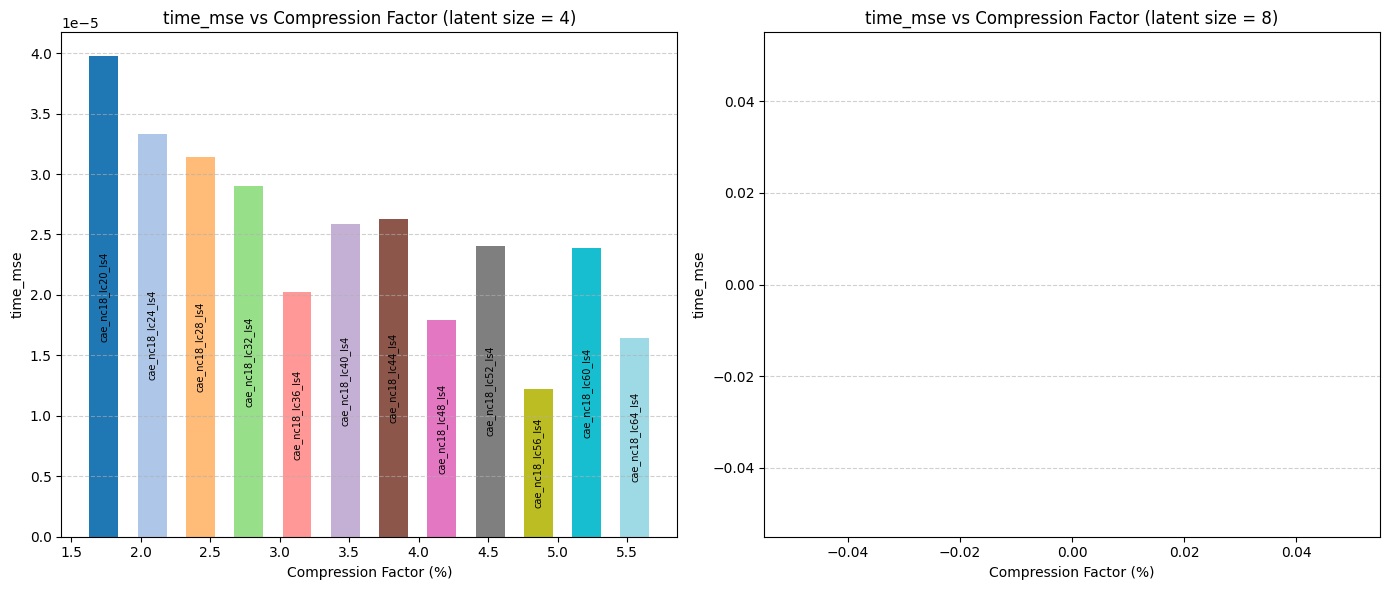

In [11]:
import os
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

root_dir = "artifacts:v0"
key = "time_mse"
original_size = 18 * 32 * 32

configs = {}
metrics = {}

# Walk through artifacts and collect config.json and metrics.json
for dirpath, _, filenames in os.walk(root_dir):
    for filename in filenames:
        if filename == "config.json" and os.path.basename(dirpath).startswith(
            "config_"
        ):
            model_name = os.path.basename(dirpath).replace("config_", "").split(":")[0]
            with open(os.path.join(dirpath, filename), "r") as f:
                configs[model_name] = json.load(f)

        elif filename == "metrics.json" and os.path.basename(dirpath).startswith(
            "metrics_"
        ):
            model_name = os.path.basename(dirpath).replace("metrics_", "").split(":")[0]
            with open(os.path.join(dirpath, filename), "r") as f:
                metrics[model_name] = json.load(f)

results = []

# Match config + metrics by model name
for model_name in configs:
    if model_name in metrics and key in metrics[model_name]:
        cfg = configs[model_name]["model"]
        latent_size = cfg["size_latent"]
        num_latent_channels = cfg["num_channels_latent"]

        latent_dims = num_latent_channels * (latent_size**2)
        compression_factor = 100 * latent_dims / original_size

        results.append(
            {
                "model": model_name,
                "latent_size": latent_size,
                "compression_factor": compression_factor,
                "time_mse": metrics[model_name][key],
            }
        )

# Remove a specific model if needed
# results = [r for r in results if r["model"] != "cae_nc18_lc48_ls4"]

# Split by latent size
results_ls4 = sorted(
    [r for r in results if r["latent_size"] == 4], key=lambda x: x["compression_factor"]
)
results_ls8 = sorted(
    [r for r in results if r["latent_size"] == 8], key=lambda x: x["compression_factor"]
)


# Helper function for plotting
def plot_group(results, title):
    compression_factors = [r["compression_factor"] for r in results]
    time_mse_values = [r["time_mse"] for r in results]
    labels = [r["model"] for r in results]

    colors = cm.tab20(np.linspace(0, 1, len(results)))

    # Auto width based on spacing
    if len(compression_factors) > 1:
        diffs = np.diff(sorted(compression_factors))
        width = min(diffs) * 0.6  # 60% of smallest gap
    else:
        width = 1.0

    bars = plt.bar(compression_factors, time_mse_values, color=colors, width=width)

    # Annotate each bar with model name *inside* the bar
    for bar, label in zip(bars, labels):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,  # middle of bar
            label,
            ha="center",
            va="center",
            fontsize=7,
            rotation=90,
            color="white" if height > 0.02 else "black",  # readable text
        )

    plt.xlabel("Compression Factor (%)")
    plt.ylabel("time_mse")
    plt.title(title)
    plt.grid(axis="y", linestyle="--", alpha=0.6)


# Create two subplots
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plot_group(results_ls4, "time_mse vs Compression Factor (latent size = 4)")

plt.subplot(1, 2, 2)
plot_group(results_ls8, "time_mse vs Compression Factor (latent size = 8)")

plt.tight_layout()
plt.show()

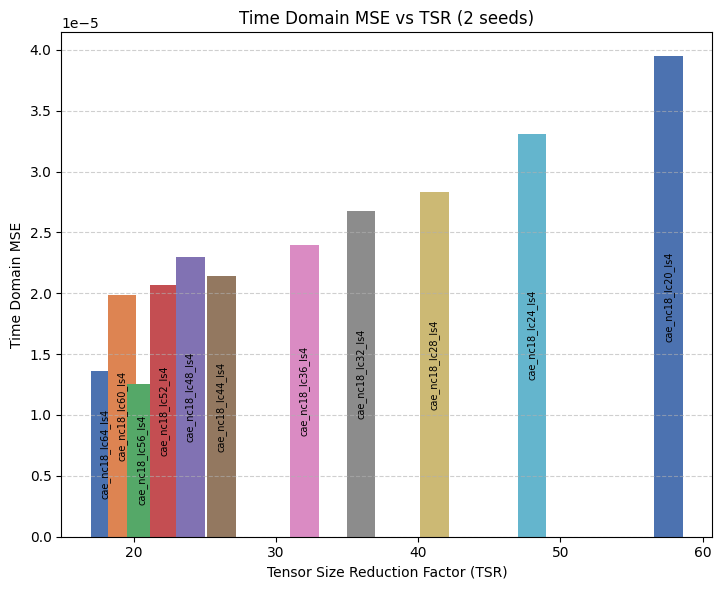

In [ ]:
import os
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from collections import defaultdict
import seaborn as sns


# You can add more root dirs here
root_dirs = ["artifacts:v0", "artifacts:v1"]
key = "time_mse"
original_size = 18 * 32 * 32

configs = {}
metrics = defaultdict(list)  # collect multiple runs per model

# Walk through artifacts and collect config.json and metrics.json
for root_dir in root_dirs:
    for dirpath, _, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename == "config.json" and os.path.basename(dirpath).startswith(
                "config_"
            ):
                model_name = (
                    os.path.basename(dirpath).replace("config_", "").split(":")[0]
                )
                with open(os.path.join(dirpath, filename), "r") as f:
                    configs[model_name] = json.load(f)

            elif filename == "metrics.json" and os.path.basename(dirpath).startswith(
                "metrics_"
            ):
                model_name = (
                    os.path.basename(dirpath).replace("metrics_", "").split(":")[0]
                )
                with open(os.path.join(dirpath, filename), "r") as f:
                    data = json.load(f)
                    if key in data:
                        metrics[model_name].append(data[key])

results = []

# Match config + averaged metrics by model name
for model_name in configs:
    if model_name in metrics and len(metrics[model_name]) > 0:
        cfg = configs[model_name]["model"]
        latent_size = cfg["size_latent"]
        num_latent_channels = cfg["num_channels_latent"]

        latent_dims = num_latent_channels * (latent_size**2)
        compression_factor = original_size / latent_dims

        avg_time_mse = np.mean(metrics[model_name])  # average across runs

        results.append(
            {
                "model": model_name,
                "latent_size": latent_size,
                "compression_factor": compression_factor,
                "time_mse": avg_time_mse,
            }
        )

results = [r for r in results if r["model"] != "cae_nc18_lc40_ls4"]

# Split by latent size
results_ls4 = sorted(
    [r for r in results if r["latent_size"] == 4], key=lambda x: x["compression_factor"]
)
# results_ls8 = sorted(
#     [r for r in results if r["latent_size"] == 8], key=lambda x: x["compression_factor"]
# )


# Helper function for plotting
def plot_group(results, title):
    compression_factors = [r["compression_factor"] for r in results]
    time_mse_values = [r["time_mse"] for r in results]
    labels = [r["model"] for r in results]

    colors = sns.color_palette(
        "deep", n_colors=len(results)
    )  # cm.tab20(np.linspace(0, 1, len(results)))

    # if len(compression_factors) > 1:
    #     diffs = np.diff(sorted(compression_factors))
    #     width = min(diffs) * 0.6
    # else:
    width = 2.0

    bars = plt.bar(compression_factors, time_mse_values, color=colors, width=width)

    for bar, label in zip(bars, labels):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            label,
            ha="center",
            va="center",
            fontsize=7,
            rotation=90,
            color="white" if height > 0.02 else "black",
        )

    plt.xlabel("Tensor Size Reduction Factor (TSR)")
    plt.ylabel("Time Domain MSE")
    plt.title(title)
    plt.grid(axis="y", linestyle="--", alpha=0.6)


# Create two subplots
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plot_group(results_ls4, "Time Domain MSE vs TSR (2 seeds)")

# plt.subplot(1, 2, 2)
# plot_group(results_ls8, "time_mse vs Compression Factor (latent size = 8)")

plt.tight_layout()
plt.show()

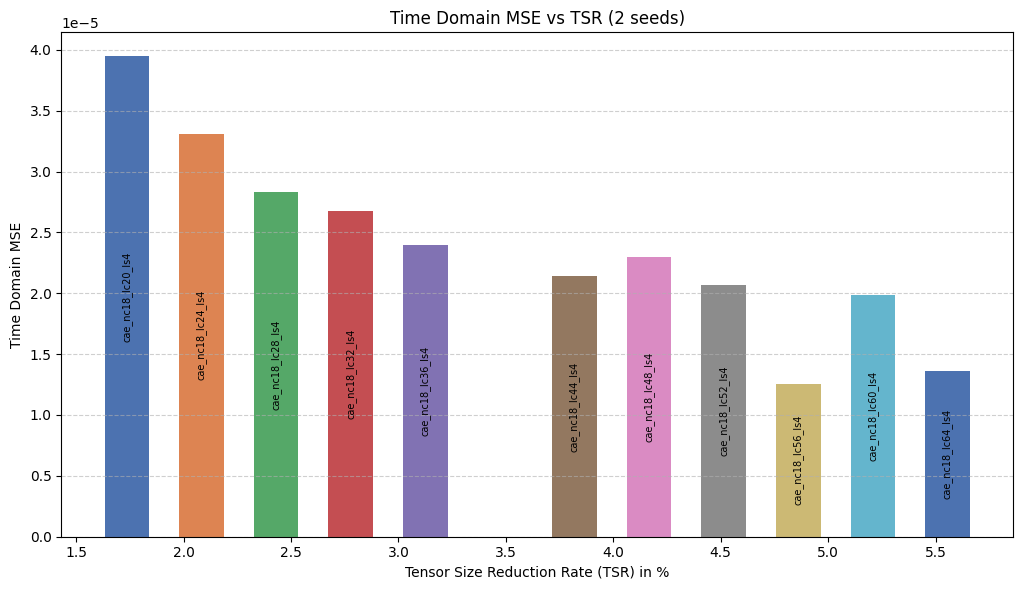

In [30]:
import os
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from collections import defaultdict
import seaborn as sns


# You can add more root dirs here
root_dirs = ["artifacts:v0", "artifacts:v1"]
key = "time_mse"
original_size = 18 * 32 * 32

configs = {}
metrics = defaultdict(list)  # collect multiple runs per model

# Walk through artifacts and collect config.json and metrics.json
for root_dir in root_dirs:
    for dirpath, _, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename == "config.json" and os.path.basename(dirpath).startswith(
                "config_"
            ):
                model_name = (
                    os.path.basename(dirpath).replace("config_", "").split(":")[0]
                )
                with open(os.path.join(dirpath, filename), "r") as f:
                    configs[model_name] = json.load(f)

            elif filename == "metrics.json" and os.path.basename(dirpath).startswith(
                "metrics_"
            ):
                model_name = (
                    os.path.basename(dirpath).replace("metrics_", "").split(":")[0]
                )
                with open(os.path.join(dirpath, filename), "r") as f:
                    data = json.load(f)
                    if key in data:
                        metrics[model_name].append(data[key])

results = []

# Match config + averaged metrics by model name
for model_name in configs:
    if model_name in metrics and len(metrics[model_name]) > 0:
        cfg = configs[model_name]["model"]
        latent_size = cfg["size_latent"]
        num_latent_channels = cfg["num_channels_latent"]

        latent_dims = num_latent_channels * (latent_size**2)
        compression_factor = 100 * latent_dims / original_size

        avg_time_mse = np.mean(metrics[model_name])  # average across runs

        results.append(
            {
                "model": model_name,
                "latent_size": latent_size,
                "compression_factor": compression_factor,
                "time_mse": avg_time_mse,
            }
        )

results = [r for r in results if r["model"] != "cae_nc18_lc40_ls4"]

# Split by latent size
results_ls4 = sorted(
    [r for r in results if r["latent_size"] == 4], key=lambda x: x["compression_factor"]
)
# results_ls8 = sorted(
#     [r for r in results if r["latent_size"] == 8], key=lambda x: x["compression_factor"]
# )


# Helper function for plotting
def plot_group(results, title):
    compression_factors = [r["compression_factor"] for r in results]
    time_mse_values = [r["time_mse"] for r in results]
    labels = [r["model"] for r in results]

    colors = sns.color_palette(
        "deep", n_colors=len(results)
    )  # cm.tab20(np.linspace(0, 1, len(results)))

    if len(compression_factors) > 1:
        diffs = np.diff(sorted(compression_factors))
        width = min(diffs) * 0.6
    else:
        width = 1.0

    bars = plt.bar(compression_factors, time_mse_values, color=colors, width=width)

    for bar, label in zip(bars, labels):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            label,
            ha="center",
            va="center",
            fontsize=7,
            rotation=90,
            color="white" if height > 0.02 else "black",
        )

    plt.xlabel("Tensor Size Reduction Rate (TSR) in %")
    plt.ylabel("Time Domain MSE")
    plt.title(title)
    plt.grid(axis="y", linestyle="--", alpha=0.6)


# Create two subplots
plt.figure(figsize=(20, 6))

plt.subplot(1, 2, 1)
plot_group(results_ls4, "Time Domain MSE vs TSR (2 seeds)")

# plt.subplot(1, 2, 2)
# plot_group(results_ls8, "time_mse vs Compression Factor (latent size = 8)")

plt.tight_layout()
plt.show()